In [4]:
%load_ext autoreload 
%autoreload 2

In [ ]:
# %%

from ssa.market import LabourMarket, ExperimentLog, Job
from ssa.agents import StaticAgent, LLMAgent, OracleAgent, ImproveAgent
from ssa.tasks.cipher import CipherAgent, CipherTask
from ssa.tasks import ProxyAgent, ProxyTask
from ssa.utils import init_azure_model
from tqdm import trange
import numpy as np

task_ids = ["task_a", "task_b", "task_c"]
tasks = [ProxyTask(t) for t in task_ids]

jobs = [Job(id=f"{task_id}_{i}", task_id=task_id, base_reward=7+i) for task_id in task_ids for i in range(3)]

agents = [ImproveAgent(agent_id=f"imp_{i}", jobs=jobs, model=None, verbose=False) for i in range(5)]
agents.append(LLMAgent(agent_id=f"llm_0", jobs=jobs, model=None, verbose=True))

market = LabourMarket(jobs=jobs, tasks=tasks, agents=agents, p=0.1, t=0.001, rep_sensitivity=1)
for _ in trange(20):
    market.simulate_timestep()


2025-09-02 15:11:44.573 | INFO     | ssa.market:__init__:94 - Set up LabourMarket with 2 agents and 3 tasks. Initializing...
  0%|          | 0/20 [00:00<?, ?it/s]2025-09-02 15:11:44.577 | INFO     | ssa.agents.llm:get_agent_action:118 - === ROUND 1 ===

RECENT MARKET ACTIVITY (Last 10 rounds):
This is Round 1. No history recorded yet.

YOUR RECENT ACTIONS:

>> REPUTATION (Last Known Round) - cip_c: 0.38 (R0) | cip_b: 0.38 (R0) | cip_a: 0.38 (R0)

THIS ROUND'S LISTINGS (task_id: job_id@client_budget, grouped by task types):
cip_a: cip_a_0@10.0, cip_a_1@10.0
cip_b: cip_b_0@10.0, cip_b_1@10.0
cip_c: cip_c_0@10.0, cip_c_1@10.0

2025-09-02 15:11:44.578 | INFO     | ssa.agents.llm:get_agent_action:118 - === ROUND 1 ===

RECENT MARKET ACTIVITY (Last 10 rounds):
This is Round 1. No history recorded yet.

YOUR RECENT ACTIONS:

>> REPUTATION (Last Known Round) - cip_c: 0.38 (R0) | cip_b: 0.38 (R0) | cip_a: 0.38 (R0)

THIS ROUND'S LISTINGS (task_id: job_id@client_budget, grouped by task types):


0.3222872705007177
0.3365383369512343
0.27419670618964714
0.29662424056597897
0.36561383707741246
0.3818463390421138
0.35657670157748955
0.377411055838436
0.3269785628639927
0.3507911940195812
0.3966620013380784
0.41643335350109784


In [3]:
exp_log = market.export()

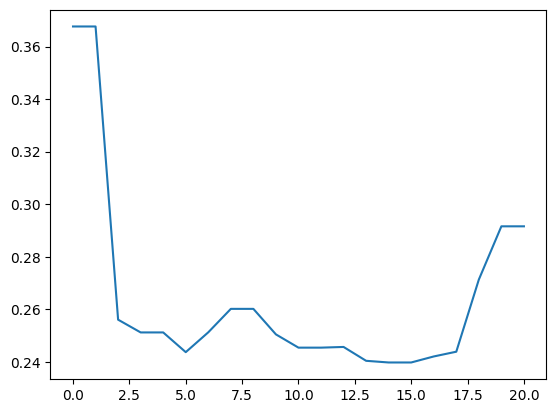

In [5]:
import matplotlib.pyplot as plt

plt.plot(exp_log.reputation_history['cip_a'][0])

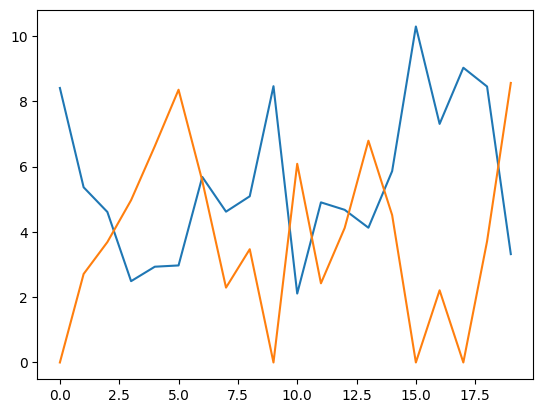

In [20]:
import matplotlib.pyplot as plt

plt.plot(np.array(exp_log.agent_reward_history).T, label=exp_log.agent_ids)